In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
%matplotlib inline

sns.set_theme('notebook', palette='muted')


In [2]:
filename=r'D:\HopeAI\Assignments\ML and DS Capstone\4. Feature Selection\full_dataset.pkl'
dataset = pickle.load(open(filename,'rb'))



## 1. What is the Percent of Stocks by Categories

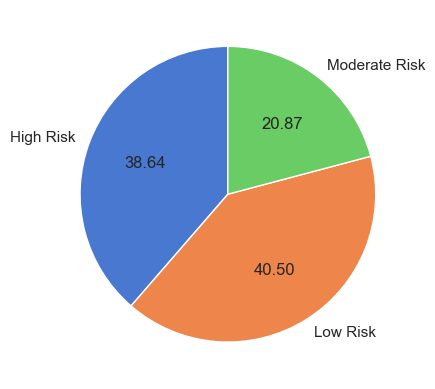

In [3]:
counts = dataset['Categories'].value_counts().sort_index()
labels = counts.index.tolist()
values = counts.values.tolist()

plt.pie(x=values, labels=labels, autopct='%.2f', startangle=90)
plt.show()


## 2. How many Stock Categories are there on each Sectors

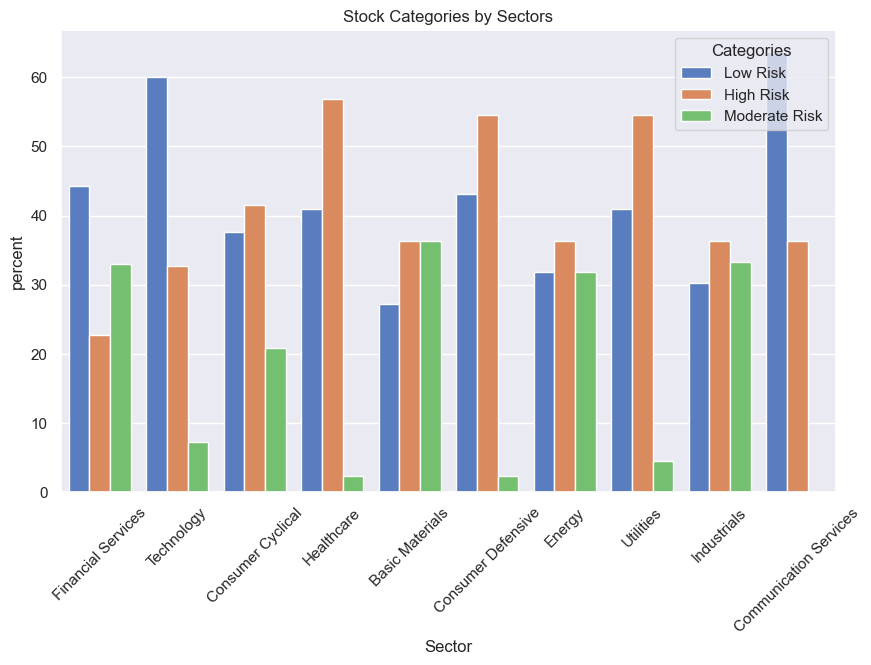

In [4]:
sector_data = dataset[['Categories','Sector']].value_counts().reset_index(name='count')
sector_data['percent'] = sector_data.groupby('Sector')['count'].transform(lambda x: 100 * x / x.sum())

plt.figure(figsize=[10,6])
sns.barplot(sector_data, x='Sector',
            y='percent',hue='Categories', errorbar=None)
plt.xticks(rotation=45)
plt.title('Stock Categories by Sectors')
plt.show()


## 3. How many times each Stocks Occurrs on each Category 

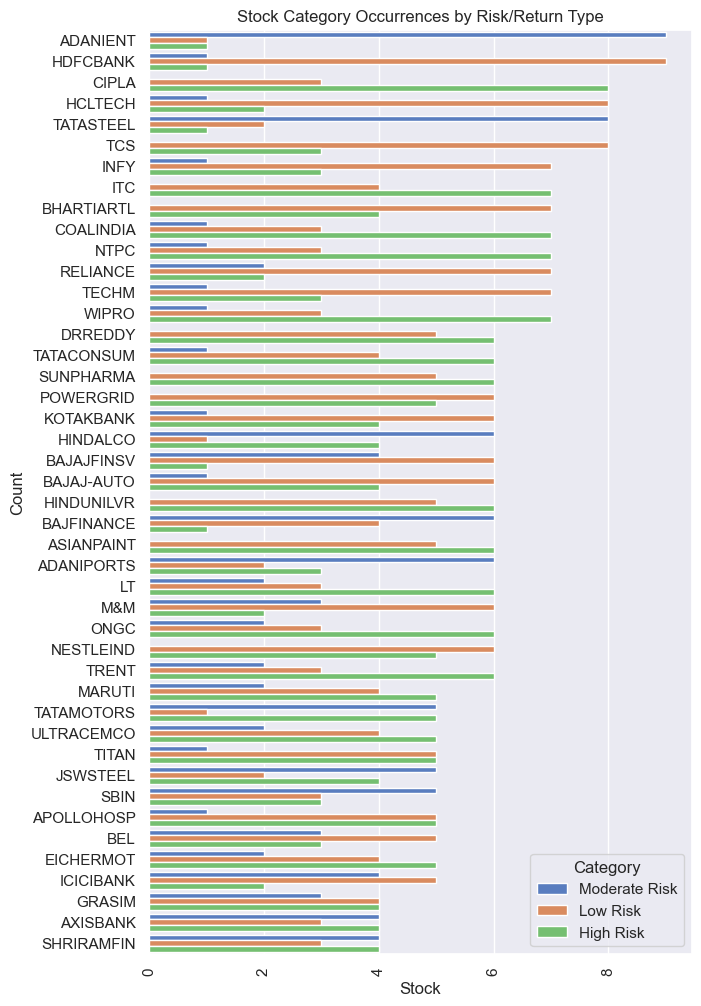

In [5]:
stk_data = dataset[['Stock','Categories']].value_counts().reset_index()

plt.figure(figsize=(7,12))
sns.barplot(y='Stock', x='count', hue='Categories', data=stk_data, dodge=True)
plt.xticks(rotation=90)
plt.title('Stock Category Occurrences by Risk/Return Type')
plt.xlabel('Stock')
plt.ylabel('Count')
plt.legend(title='Category')
plt.show()


## 4. What is Market Capitalization Distribution Across Risk-Return Categories?

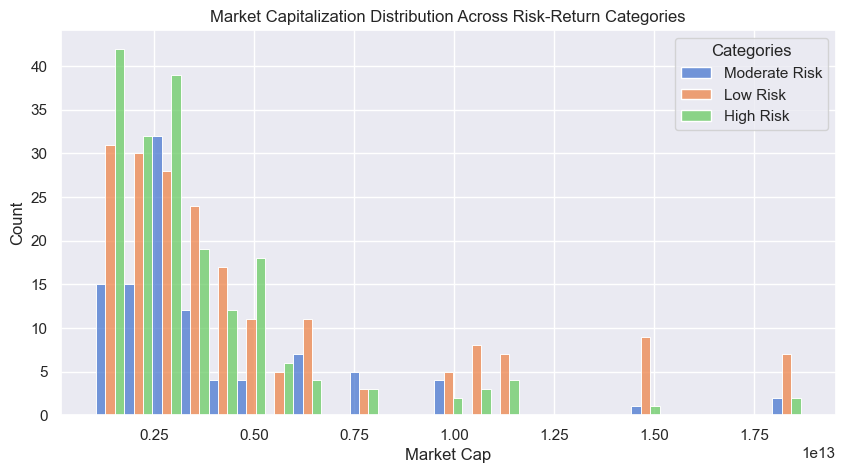

In [6]:
plt.figure(figsize=[10,5])
sns.histplot(dataset,x='Market Cap', hue='Categories', multiple='dodge')
plt.title('Market Capitalization Distribution Across Risk-Return Categories')
plt.show()


## 5. Compare the Risk Metrics Across each Categories

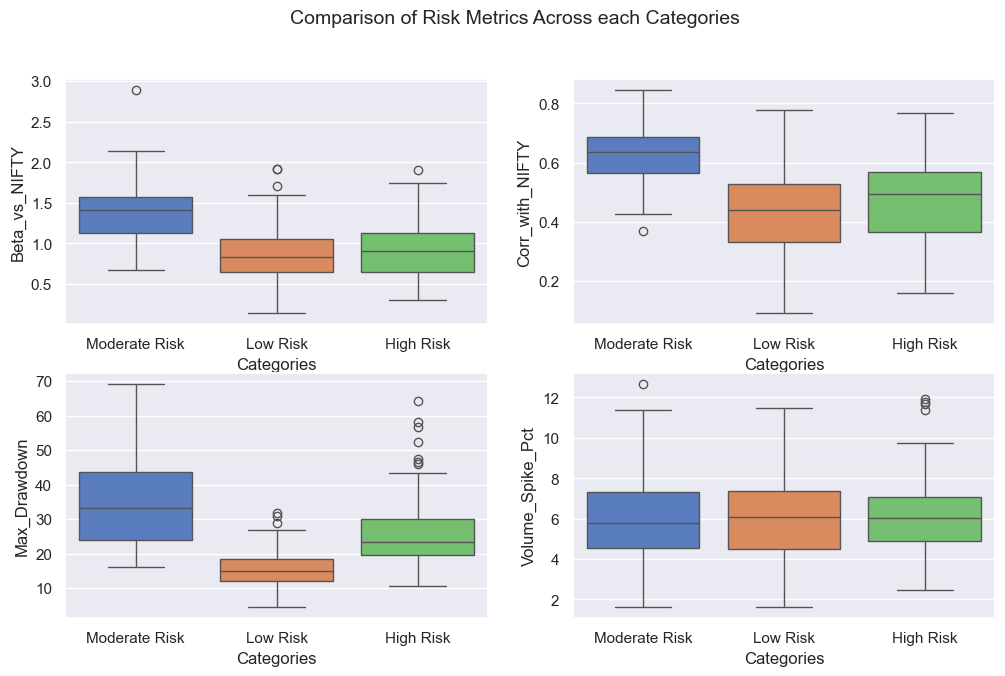

In [7]:
fig, axes = plt.subplots(2,2, figsize=[12,7])
sns.boxplot(dataset, x='Categories', y='Beta_vs_NIFTY', hue='Categories', ax=axes[0,0])
sns.boxplot(dataset, x='Categories', y='Corr_with_NIFTY', hue='Categories', ax=axes[0,1])
sns.boxplot(dataset, x='Categories', y='Max_Drawdown', hue='Categories', ax=axes[1,0])
sns.boxplot(dataset, x='Categories', y='Volume_Spike_Pct', hue='Categories', ax=axes[1,1])
fig.suptitle('Comparison of Risk Metrics Across each Categories', fontsize=14)
plt.show()


## 6. What is the Trend of Stock Counts by each Categories Over Years

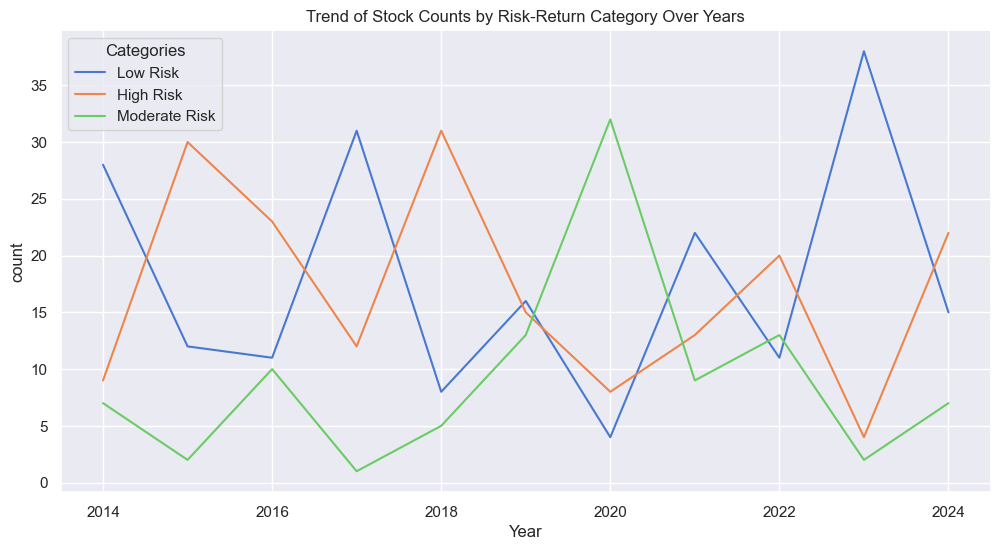

In [8]:
year_cat = dataset[['Year', 'Categories']].value_counts().reset_index()
year_cat = year_cat.sort_values('Year').reset_index(drop=True)

plt.figure(figsize=[12,6])
sns.lineplot(year_cat, x='Year', y='count', hue='Categories')
plt.title('Trend of Stock Counts by Risk-Return Category Over Years')
plt.show()


## 7. What is the Total Annual Return Distribution on every Categories?

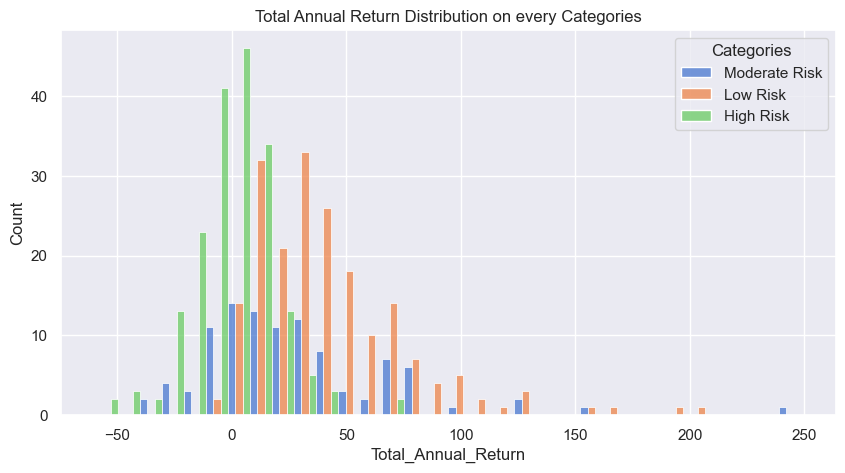

In [9]:
plt.figure(figsize=[10,5])
sns.histplot(dataset, x='Total_Annual_Return', hue='Categories', multiple='dodge')
plt.title('Total Annual Return Distribution on every Categories')
plt.show()


## 8. What is the Distribution of Positive Days Percentage by Category

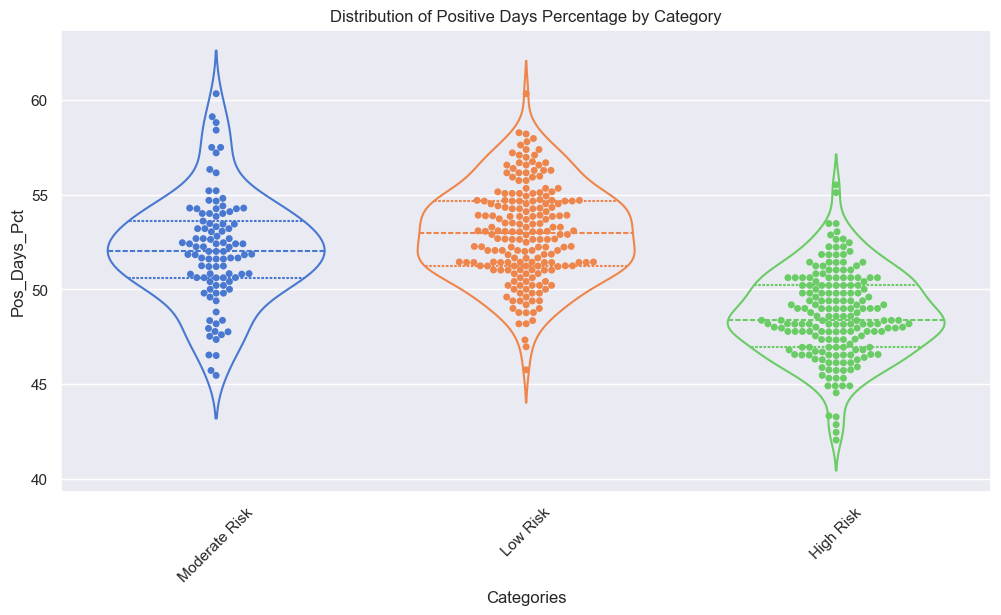

In [10]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=dataset, x='Categories', y='Pos_Days_Pct', inner='quartile', hue='Categories', fill=False, width=0.7)
sns.swarmplot(dataset, x='Categories', y='Pos_Days_Pct', hue='Categories')
plt.title("Distribution of Positive Days Percentage by Category")
plt.xticks(rotation=45)
plt.show()


## 9. What is the Average Daily Trading Range Distribution Across Categories?

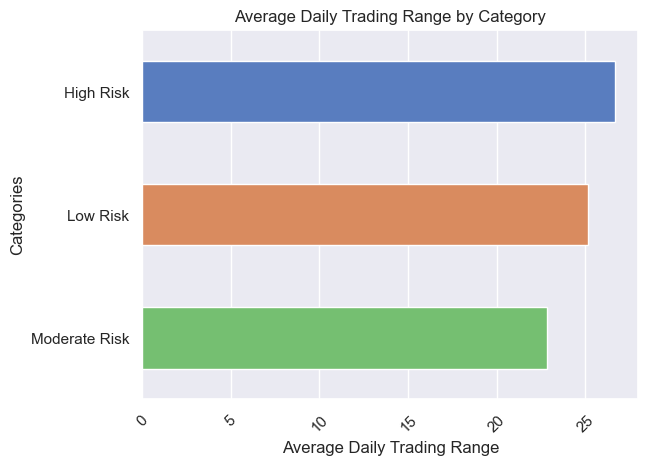

In [11]:
dailytr_cat = dataset.groupby('Categories')['Avg_Daily_TR'].mean()

sns.barplot(x=dailytr_cat.values, y=dailytr_cat.index,
            hue=dailytr_cat.index, errorbar=None, width=0.5)
plt.title('Average Daily Trading Range by Category')
plt.xticks(rotation=45)
plt.xlabel('Average Daily Trading Range')
plt.show()


## 10. Top 3 stocks with Highest and Lowest Total Annual Return on each Categories

In [12]:
categories = ['Low Risk', 'Moderate Risk', 'High Risk']

for cat in categories:
    disp_data = dataset[dataset['Categories'] == cat][['Stock', 'Year', 'Total_Annual_Return']]
    print(f'\n{cat} Stocks\n')
    print('Top 3 Stocks with Highest Annual Return')
    print(disp_data.sort_values('Total_Annual_Return', ascending=False).head(3).reset_index(drop=True))
    print('Top 3 Stocks with Lowest Annual Return')
    print(disp_data.sort_values('Total_Annual_Return').head(3).reset_index(drop=True))



Low Risk Stocks

Top 3 Stocks with Highest Annual Return
        Stock  Year  Total_Annual_Return
0   EICHERMOT  2014           203.034105
1         BEL  2014           191.696093
2  TATACONSUM  2017           163.699389
Top 3 Stocks with Lowest Annual Return
     Stock  Year  Total_Annual_Return
0  DRREDDY  2021            -5.948982
1  DRREDDY  2015            -2.652264
2      TCS  2016            -0.325909

Moderate Risk Stocks

Top 3 Stocks with Highest Annual Return
        Stock  Year  Total_Annual_Return
0    ADANIENT  2021           248.281489
1  TATAMOTORS  2021           158.659524
2    ADANIENT  2020           132.407014
Top 3 Stocks with Lowest Annual Return
       Stock  Year  Total_Annual_Return
0   ADANIENT  2015           -37.685498
1  TATASTEEL  2015           -33.878126
2        M&M  2019           -30.307944

High Risk Stocks

Top 3 Stocks with Highest Annual Return
   Stock  Year  Total_Annual_Return
0  CIPLA  2020            73.644175
1  TRENT  2017            67.7